# WCC ETC 

### Import main package

In [1]:
from importlib import reload
import wcc_etc
reload(wcc_etc)

<module 'wcc_etc' from '/Users/gudmundurstefansson/anaconda3/envs/py313/lib/python3.13/site-packages/wcc_etc/__init__.py'>

### Initialize

In [3]:
WCC = wcc_etc.WCCETC("../config/config_wcc_sdssr_from_final_EOL_qCMOS.toml")
WCC.setup(verbose=True)

Initializing WCC ETC. Reading in Config
Setting up WCC ETC with current configuration
Reading total throughput from file
'path_gain_curve'
'path_dark_current'
'path_read_noise'
'path_well_depth'
##################################################
# System Summary from .toml configuration file
# Main
Diameter Primary:            3.06 m
Fnum:                        15.0
Focal Length:               45.98 m
Num mirrors:                  0.0
Surf Area:                   7.38 m2m2

# Detector
Gain Setting:     
Gain:                      8.9000 electron / ct
Sensor Area:                199.7 mm2mm2
Pixel Size:                 4.600 um / pix
Read Noise:                 0.280 electron(1/2) / pix(1/2)
Dark Current:              0.0040 electron / (pix s)
Well depth:                7000.0 electron / pix
# Other
Plate Scale:                0.021 arcsec/pix
Zodi S. brightn.:            22.5 mag/arcsec2
#################################################


Initializing WCC ETC. Reading in Config
Setting up WCC ETC with current configuration
'path_gain_curve'
'path_dark_current'
'path_read_noise'
'path_well_depth'
Number of PSF pixels: 196.0 pix
###################################################
# Main
Diameter Primary:                 3.06 m
Fnum:                             15.0
Focal Length:                    45.98 m
Num mirrors:                       4.0
Surf Area:                        7.38 m2m2

# Detector
Gain Setting:     
Gain:                          10.0000 electron / ct
Sensor Area:                     864.0 mm2mm2
Pixel Size:                      3.450 um / pix
Read Noise:                     90.000 electron(1/2) / pix(1/2)
Dark Current:                 100.0000 electron / (pix s)
Well depth:                    30000.0 electron / pix
# Other
Plate Scale:                     0.015
Num PSF Pixels:                  196.0 pix
###################################################


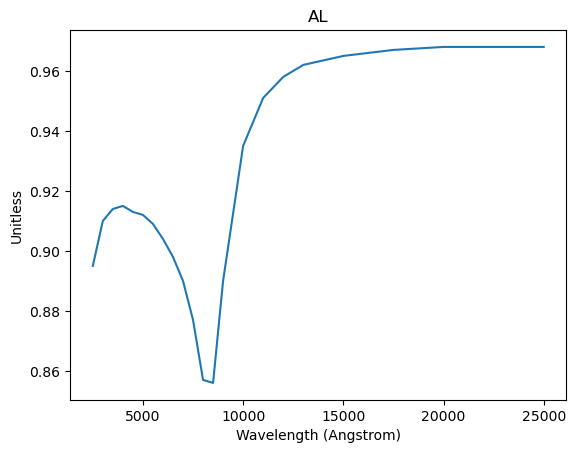

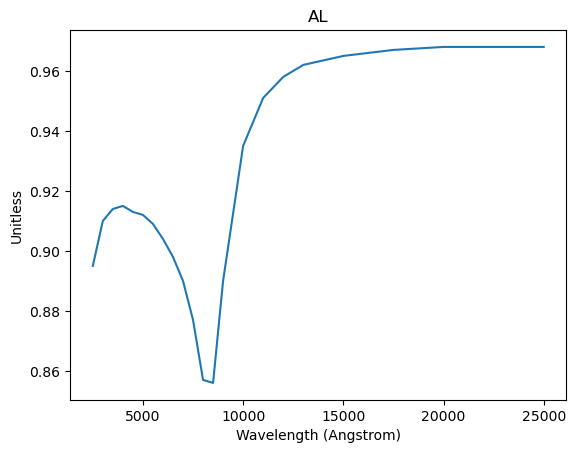

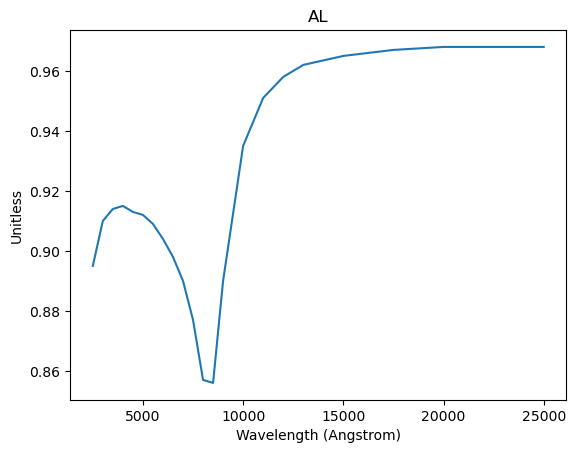

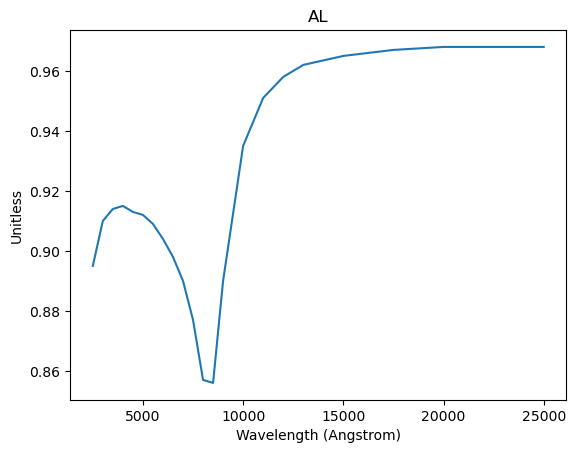

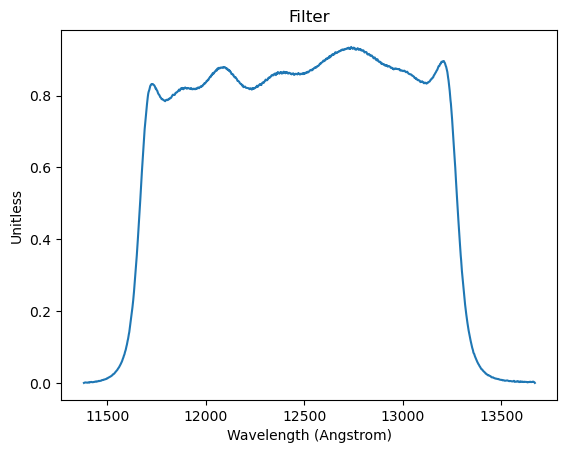

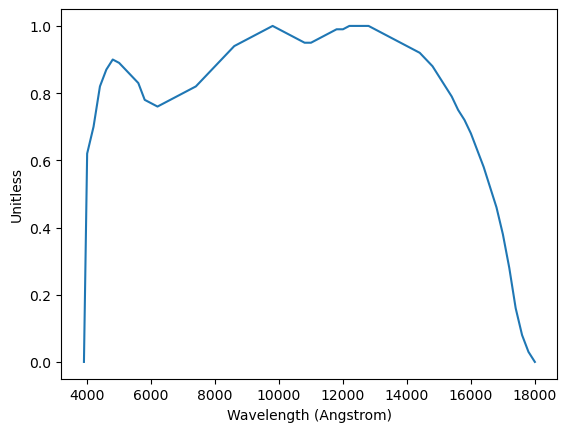

In [2]:
WCC = wcc_etc.WCCETC("../config/config_wcc_nir.toml")
WCC.setup(verbose=True)

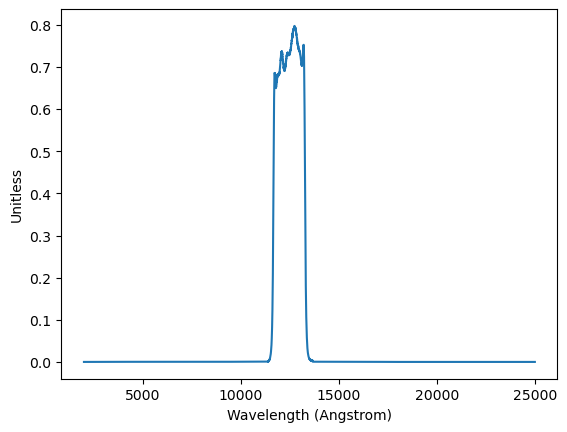

In [3]:
# Plot full bandpass
WCC.bandpass.plot()
#WCC.bandpass._gt_arrays(None)

# Calculate SNR for a given exposure time and magnitude

Stellar mag: 20
No background Mag provided, using Zodi background (25.821 mag, 22.5mag/arc2)
Source Counts: 389.18517250602076 electron / se/s
Source Counts: 38.91851725060208 ct / sADU/s
Background Counts: 3.4643541568039957 electron / se/s
Background Counts: 0.3464354156803996 ct / sADU/s
########################
Saturation time: 14975.187 s
########################
1669.4786526337405 electron(1/2)
SNR=13.99: in 60.000s


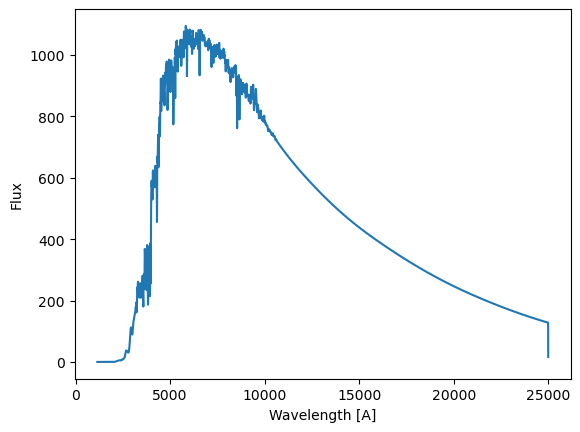

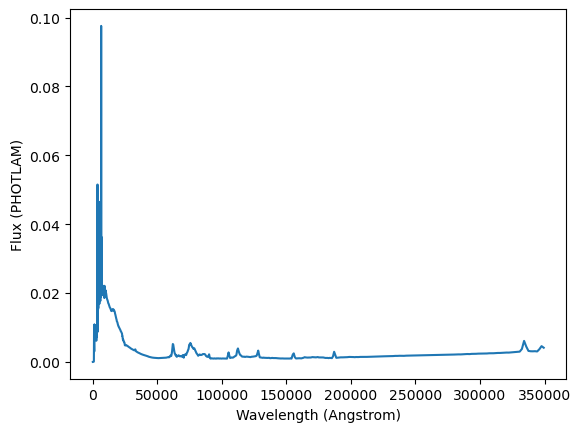

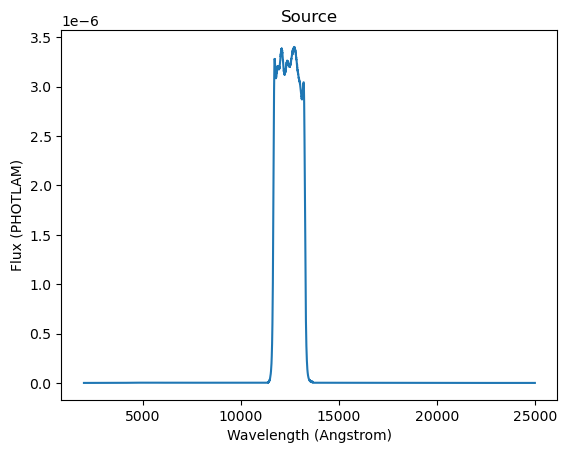

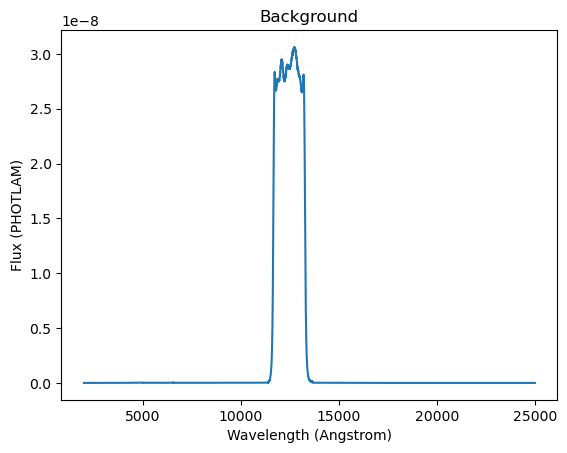

In [ ]:
import os
from astropy import units as u
uasal_archive = os.environ.get("UASAL_ARCHIVE")

#MAG = 5 # AB mag
MAG = 20 # AB mag
BKG_MAG = 180 # vmag / arcsec2 # make background irrelevant
SNR = 10.
#frame_time = 10000000000. #
source_file = '/Users/gks/Dropbox/mypylib/notebooks/GIT/USAL_ARCHIVE/2025-06-16_uasal_archive_repo/astr_obj_models/stars/pickles_models/dat_uvk/pickles_uk_55.fits'
bkg_file = 'ngc_2537_spec.fits'

print('Stellar mag:',MAG)
w, y = WCC.set_source(source_file,plot=True)

WCC.set_background(background_file=bkg_file,support_data_path=f'{uasal_archive}/astr_obj_models/galaxies/brown/', plot=True)
#WCC.make_observation(flux=MAG, bg_flux=BKG_MAG, plot=True, verbose=True)
WCC.make_observation(flux=MAG, bg_flux=None, plot=True, verbose=True)

# Calculate the CCD's Saturation Time
print('########################')
sat_time = WCC.calc_saturation_time()
print('Saturation time: {:0.3f}'.format(sat_time))

# Calculate time to given SNR
#print('########################')
#t_int = WCC.calc_int_time(snr=SNR,exp_time=sat_time*0.9)
#print('Time to get to SNR={}: {:0.3f}'.format(SNR,t_int))

# Calculate SNR in exptime
print('########################')
texp = 60
#texp = 900
snr = WCC.calc_SNR(int_time=texp*u.s,exp_time=texp*u.s)
print('SNR={:0.2f}: in {:0.3f}s'.format(snr,texp))
#snr = WCC.calc_SNR_one_frame_with_gain(exp_time=texp)
#print('SNR={}: in {:0.3f}'.format(snr,texp))
